In [69]:
import pandas as pd

df = pd.read_csv("training_dataset.csv")

print(df.shape)
df.head()

(6048, 25)


,Likes_Beach,Likes_Mountain,Likes_Culture,Likes_Adventure,Budget,Total_Days,Cluster_Name,Adventure,Architecture,Beach,...,Nature,Park,Relax,Religious,Safari,Shopping,Viewpoint,Num_Places,Avg_Distance,Score
0,1,0,0,1,2,7,Dambulla Area,0.0,0.018519,0.000000,...,0.166667,0.000000,0.055556,0.018519,0.111111,0.000000,0.055556,0.791667,0.427961,9.07
1,0,1,1,0,3,2,Kurunegala,0.0,0.000000,0.000000,...,0.243243,0.027027,0.081081,0.216216,0.000000,0.027027,0.081081,0.437500,0.164374,81.36
2,1,1,0,0,1,2,Hambantota Area,0.0,0.024390,0.048780,...,0.268293,0.000000,0.024390,0.146341,0.121951,0.000000,0.048780,0.520833,0.715727,27.46
3,1,1,1,0,2,3,Anuradhapura,0.0,0.021739,0.000000,...,0.152174,0.021739,0.043478,0.173913,0.000000,0.021739,0.043478,0.625000,0.437584,46.51
4,1,0,0,1,3,5,Talaimannar Area,0.0,0.000000,0.095238,...,0.142857,0.000000,0.047619,0.190476,0.095238,0.000000,0.095238,0.104167,0.614522,25.03


In [70]:
print(df.isnull().sum())

Likes_Beach        0
Likes_Mountain     0
Likes_Culture      0
Likes_Adventure    0
Budget             0
Total_Days         0
Cluster_Name       0
Adventure          0
Architecture       0
Beach              0
Birding            0
Culture            0
Hiking             0
History            0
Museum             0
Nature             0
Park               0
Relax              0
Religious          0
Safari             0
Shopping           0
Viewpoint          0
Num_Places         0
Avg_Distance       0
Score              0
dtype: int64


In [71]:
df = df.dropna()

In [72]:
print(df.dtypes)

Likes_Beach          int64
Likes_Mountain       int64
Likes_Culture        int64
Likes_Adventure      int64
Budget               int64
Total_Days           int64
Cluster_Name        object
Adventure          float64
Architecture       float64
Beach              float64
Birding            float64
Culture            float64
Hiking             float64
History            float64
Museum             float64
Nature             float64
Park               float64
Relax              float64
Religious          float64
Safari             float64
Shopping           float64
Viewpoint          float64
Num_Places         float64
Avg_Distance       float64
Score              float64
dtype: object


In [73]:
X = df.drop(columns=['Score', 'Cluster_Name'], errors='ignore')
y = df['Score']

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [75]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# transform test data
X_test_scaled = scaler.transform(X_test)

In [76]:
print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (4838, 23)
Test shape: (1210, 23)


In [77]:
X_train

,Likes_Beach,Likes_Mountain,Likes_Culture,Likes_Adventure,Budget,Total_Days,Adventure,Architecture,Beach,Birding,...,Museum,Nature,Park,Relax,Religious,Safari,Shopping,Viewpoint,Num_Places,Avg_Distance
1934,1,1,1,0,3,2,0.058824,0.000000,0.264706,0.029412,...,0.029412,0.176471,0.000000,0.029412,0.117647,0.000000,0.000000,0.117647,0.375000,0.604089
2087,1,0,1,1,3,6,0.000000,0.018519,0.000000,0.000000,...,0.037037,0.166667,0.000000,0.055556,0.018519,0.111111,0.000000,0.055556,0.791667,0.427961
5681,0,0,0,1,2,4,0.000000,0.000000,0.125000,0.125000,...,0.062500,0.312500,0.000000,0.000000,0.062500,0.000000,0.000000,0.062500,0.000000,0.803441
3954,0,0,0,0,3,7,0.000000,0.018519,0.000000,0.000000,...,0.037037,0.166667,0.000000,0.055556,0.018519,0.111111,0.000000,0.055556,0.791667,0.427961
1094,0,1,1,1,1,1,0.000000,0.021739,0.000000,0.021739,...,0.043478,0.152174,0.021739,0.043478,0.173913,0.000000,0.021739,0.043478,0.625000,0.437584
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,0,0,1,1,3,7,0.018519,0.000000,0.000000,0.000000,...,0.037037,0.314815,0.037037,0.074074,0.018519,0.018519,0.018519,0.129630,0.791667,0.419585
5191,0,0,0,0,1,4,0.148148,0.037037,0.222222,0.000000,...,0.000000,0.185185,0.037037,0.000000,0.148148,0.037037,0.037037,0.037037,0.229167,0.721508
5226,0,1,0,0,3,7,0.157895,0.000000,0.263158,0.000000,...,0.000000,0.105263,0.000000,0.000000,0.157895,0.105263,0.000000,0.000000,0.062500,0.919824
5390,1,1,0,1,3,4,0.000000,0.000000,0.095238,0.047619,...,0.000000,0.142857,0.000000,0.047619,0.190476,0.095238,0.000000,0.095238,0.104167,0.614522


In [78]:
from sklearn.neural_network import MLPRegressor

model = MLPRegressor(
    hidden_layer_sizes=(2),   # 2 layers: 32 → 16
    activation='relu',
    solver='adam',
    alpha=0.0001,
    batch_size=32,
    learning_rate_init=0.05,
    max_iter=150,
    random_state=42,
    early_stopping=True,           # 🔥 stops automatically if no improvement
    validation_fraction=0.1,       # uses 10% of training data for validation
    n_iter_no_change=10,
    verbose=True
)

In [79]:
model.fit(X_train_scaled, y_train)

Iteration 1, loss = 537.67122160
Validation score: 0.757630
Iteration 2, loss = 62.57754135
Validation score: 0.792519
Iteration 3, loss = 59.04230619
Validation score: 0.799227
Iteration 4, loss = 58.23361493
Validation score: 0.791680
Iteration 5, loss = 57.54949497
Validation score: 0.793119
Iteration 6, loss = 57.19665378
Validation score: 0.792887
Iteration 7, loss = 56.26297893
Validation score: 0.804555
Iteration 8, loss = 55.98084109
Validation score: 0.803001
Iteration 9, loss = 54.99560398
Validation score: 0.798404
Iteration 10, loss = 54.82522947
Validation score: 0.783713
Iteration 11, loss = 55.73312278
Validation score: 0.791504
Iteration 12, loss = 55.46239146
Validation score: 0.793586
Iteration 13, loss = 55.91391845
Validation score: 0.791546
Iteration 14, loss = 55.30997940
Validation score: 0.802284
Iteration 15, loss = 55.25701455
Validation score: 0.802766
Iteration 16, loss = 56.42955099
Validation score: 0.797850
Iteration 17, loss = 55.54446772
Validation scor

,loss,'squared_error'
,hidden_layer_sizes,2
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,32
,learning_rate,'constant'
,learning_rate_init,0.05
,power_t,0.5
,max_iter,150
,shuffle,True


In [80]:
from sklearn.metrics import mean_absolute_error

# predictions
train_pred = model.predict(X_train_scaled)
test_pred = model.predict(X_test_scaled)

# MAE
train_mae = mean_absolute_error(y_train, train_pred)
test_mae = mean_absolute_error(y_test, test_pred)

print("Train MAE:", train_mae)
print("Test MAE:", test_mae)

Train MAE: 8.233055210142986
Test MAE: 8.320409751016177


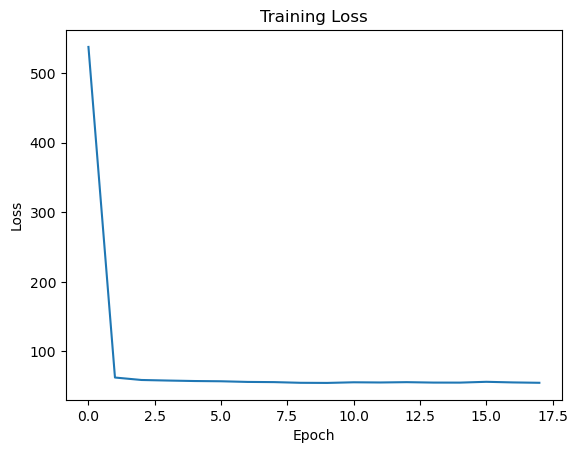

In [81]:
import matplotlib.pyplot as plt

plt.plot(model.loss_curve_)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [82]:
import joblib

joblib.dump(model, "mlp_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

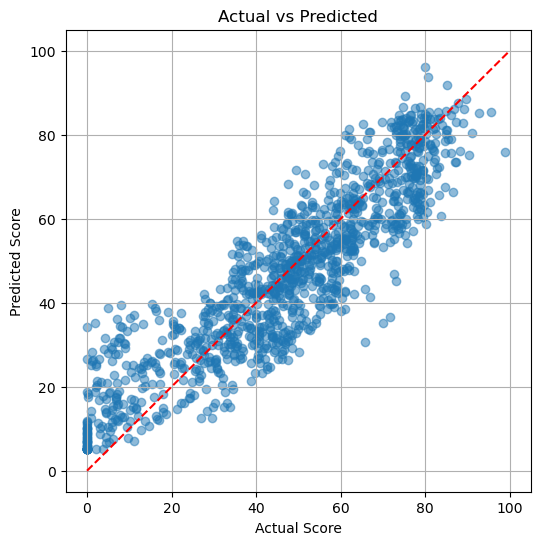

In [83]:
import matplotlib.pyplot as plt

# make predictions
y_test_pred = model.predict(X_test_scaled)

# scatter plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred, alpha=0.5)

# perfect prediction line
plt.plot([0, 100], [0, 100], color='red', linestyle='--')

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted")

plt.grid(True)
plt.show()

In [84]:
from sklearn.metrics import mean_absolute_error, r2_score

y_test_pred = model.predict(X_test_scaled)

print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("R2:", r2_score(y_test, y_test_pred))

MAE: 8.320409751016177
R2: 0.8061753571104708


In [85]:
import pandas as pd

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred
})

print(results.head(20))

    Actual  Predicted
0    48.22  48.973806
1    73.66  83.429450
2    64.51  64.150276
3    75.22  89.315678
4    57.51  51.471408
5    62.67  71.817974
6    77.52  81.285089
7    98.91  75.788246
8    72.37  56.972418
9    62.37  54.334947
10   39.87  33.355438
11   62.01  79.534233
12   26.59  24.077235
13   41.15  55.494085
14   75.66  69.821223
15   50.86  45.337610
16   51.59  56.972190
17   69.10  69.716653
18   57.87  45.951931
19   40.11  39.612563
